# CALIDAD DE DATOS

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Automcompletar rápido
%config IPCompleter.greedy=True

#Desactivar notación científica
pd.options.display.float_format = '{:,.2f}'.format

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
from credit_scoring.config import INTERIM_DATA_DIR

ruta_proyecto = INTERIM_DATA_DIR

2026-09-15 15:55:21.274 | INFO     | credit_scoring.config:<module>:11 - PROJ_ROOT path is: /home/isailzc/credit_scoring/credit_scoring


In [3]:
nombre_archivo_datos = 'trabajo.csv'

Cargar los datos.

In [4]:
ruta_completa = INTERIM_DATA_DIR / nombre_archivo_datos

df = pd.read_csv(ruta_completa,index_col='id_cliente')
df

,Unnamed: 0,empleo,antigüedad_empleo,ingresos,ingresos_verificados,rating,dti,vivienda,num_hipotecas,num_lineas_credito,...,id_prestamo,descripcion,finalidad,principal,tipo_interes,num_cuotas,imp_cuota,imp_amortizado,estado,imp_recuperado
id_cliente,,,,,,,,,,,,,,,,,,,,,
4798121,1,"Target Promotions and Marketing,Inc",10+ years,"65,000.00",Not Verified,D,25.40,RENT,1.00,15.00,...,NaN,NaN,debt_consolidation,"10,000.00",17.77,36 months,360.38,"6,362.96",Charged Off,0.00
46641215,2,Banker,5 years,"135,000.00",Verified,A,14.68,RENT,0.00,19.00,...,NaN,NaN,debt_consolidation,"24,000.00",6.39,36 months,734.38,"24,000.00",Fully Paid,0.00
87998444,3,executive director,9 years,"188,000.00",Source Verified,B,11.69,MORTGAGE,3.00,15.00,...,NaN,NaN,credit_card,"27,000.00",8.99,60 months,560.35,"12,443.00",Current,0.00
131289518,5,NaN,10+ years,"72,777.00",Source Verified,D,24.74,MORTGAGE,2.00,10.00,...,NaN,NaN,home_improvement,"25,000.00",21.85,60 months,688.35,"2,811.27",Current,0.00
103448519,7,Web site administrator,10+ years,"99,800.00",Not Verified,A,9.69,MORTGAGE,0.00,8.00,...,NaN,NaN,credit_card,"9,600.00",5.32,36 months,289.11,"6,228.92",Current,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119242742,199994,NaN,NaN,"20,000.00",Source Verified,C,8.02,RENT,0.00,5.00,...,NaN,NaN,debt_consolidation,"2,500.00",12.62,36 months,83.78,996.06,Late (31-120 days),0.00
51876926,199995,Office Manager,10+ years,"42,000.00",Not Verified,C,20.85,MORTGAGE,6.00,9.00,...,NaN,NaN,debt_consolidation,"8,000.00",12.29,36 months,266.83,"8,000.00",Fully Paid,0.00
121031962,199996,Owner & President,6 years,"111,697.00",Verified,B,16.63,MORTGAGE,2.00,10.00,...,NaN,NaN,other,"10,000.00",9.44,36 months,320.05,"4,388.51",Current,0.00


## VISIÓN GENERAL

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 140000 entries, 4798121 to 94394801
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   140000 non-null  int64  
 1   empleo                       129690 non-null  object 
 2   antigüedad_empleo            130948 non-null  object 
 3   ingresos                     140000 non-null  float64
 4   ingresos_verificados         140000 non-null  object 
 5   rating                       140000 non-null  object 
 6   dti                          139898 non-null  float64
 7   vivienda                     140000 non-null  object 
 8   num_hipotecas                136927 non-null  float64
 9   num_lineas_credito           139997 non-null  float64
 10  porc_tarjetas_75p            135391 non-null  float64
 11  porc_uso_revolving           139891 non-null  float64
 12  num_cancelaciones_12meses    139992 non-null  floa

### Corrección

Eliminar la variable Unnamed: 0

In [6]:
df.drop(columns='Unnamed: 0',inplace=True)

## TIPOS DE DATOS

### Identificación

In [7]:
df.dtypes

empleo                          object
antigüedad_empleo               object
ingresos                       float64
ingresos_verificados            object
rating                          object
dti                            float64
vivienda                        object
num_hipotecas                  float64
num_lineas_credito             float64
porc_tarjetas_75p              float64
porc_uso_revolving             float64
num_cancelaciones_12meses      float64
num_derogatorios               float64
num_meses_desde_ult_retraso    float64
id_prestamo                    float64
descripcion                     object
finalidad                       object
principal                      float64
tipo_interes                   float64
num_cuotas                      object
imp_cuota                      float64
imp_amortizado                 float64
estado                          object
imp_recuperado                 float64
dtype: object

Conclusiones:

* Todo correcto en cuanto a tipo de datos

## VALORES ÚNICOS

### Identificación

In [8]:
df.nunique().sort_values()

id_prestamo                        0
num_cuotas                         2
ingresos_verificados               3
vivienda                           6
num_cancelaciones_12meses          7
rating                             7
estado                             9
antigüedad_empleo                 11
finalidad                         14
num_derogatorios                  20
num_hipotecas                     25
num_lineas_credito                65
num_meses_desde_ult_retraso      132
porc_tarjetas_75p                173
tipo_interes                     580
porc_uso_revolving              1101
principal                       1463
dti                             5297
descripcion                     7771
imp_recuperado                 10599
ingresos                       11675
imp_cuota                      33539
empleo                         54479
imp_amortizado                 57851
dtype: int64

Conclusiones:

* id_prestamo con menos de 2 valores --> eliminar

### Corrección

In [9]:
df.drop(columns = 'id_prestamo', inplace = True)

## DUPLICADOS

### Identificación

In [10]:
df.duplicated().sum()

0

## SEPARAR NUMÉRICAS Y CATEGÓRICAS

### Categóricas

In [11]:
cat = df.select_dtypes(exclude = 'number').copy()

### Numéricas

In [12]:
num = df.select_dtypes(include='number').copy()

## GESTIÓN DE CATEGÓRICAS

### Nulos

#### Identificación

In [13]:
cat.isna().sum().sort_values(ascending = False)

descripcion             132207
empleo                   10310
antigüedad_empleo         9052
ingresos_verificados         0
rating                       0
vivienda                     0
finalidad                    0
num_cuotas                   0
estado                       0
dtype: int64

In [14]:
cat.descripcion.value_counts(dropna=False)

NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     132207
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            11
credit card debt consolidation            

In [15]:
cat.empleo.value_counts(dropna=False)

NaN                               10310
Teacher                            2448
Manager                            2210
Owner                              1371
Registered Nurse                   1000
                                  ...  
Substance abuse counselor             1
operations mgr                        1
Credit Analyst 3                      1
Dealer Channel Account Manager        1
Owner & President                     1
Name: empleo, Length: 54480, dtype: int64

In [16]:
cat.antigüedad_empleo.value_counts(dropna=False)

10+ years    46117
2 years      12523
< 1 year     11884
3 years      11215
1 year        9124
NaN           9052
5 years       8728
4 years       8547
6 years       6334
7 years       5800
8 years       5739
9 years       4937
Name: antigüedad_empleo, dtype: int64

Conclusiones:

* sustituir todas por valor 'desconocido'

#### Corrección

##### Imputar por un valor

###### Variables a imputar

In [17]:
var_imputar_desconocido = ['descripcion','empleo','antigüedad_empleo']

###### Imputar

In [18]:
cat[var_imputar_desconocido] = cat[var_imputar_desconocido].fillna('desconocido')

## GESTIÓN DE NUMÉRICAS

### Nulos

#### Identificación

In [19]:
num.isna().sum().sort_values(ascending = False)

num_meses_desde_ult_retraso    71743
porc_tarjetas_75p               4609
num_hipotecas                   3073
porc_uso_revolving               109
dti                              102
num_cancelaciones_12meses          8
num_lineas_credito                 3
num_derogatorios                   3
ingresos                           0
principal                          0
tipo_interes                       0
imp_cuota                          0
imp_amortizado                     0
imp_recuperado                     0
dtype: int64

Veamoslas con más detalle.

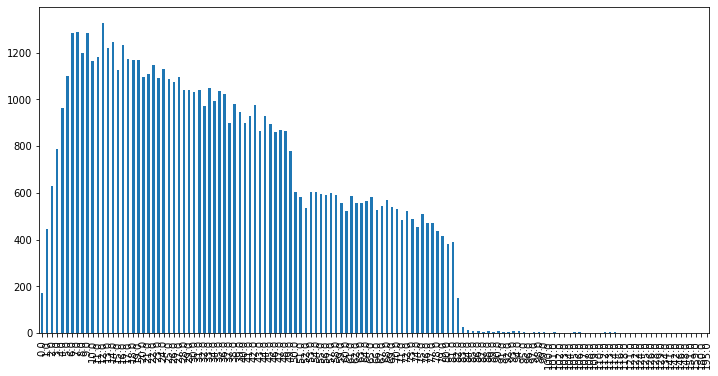

In [20]:
num.num_meses_desde_ult_retraso.value_counts().sort_index().plot.bar(figsize = (12,6));

Hay ceros, pero parecen pocos para una variable que implica retrasos.

Así que vamos a pensar que los nulos significan que no ha habido retrasos.

Y por tanto imputar por ceros.

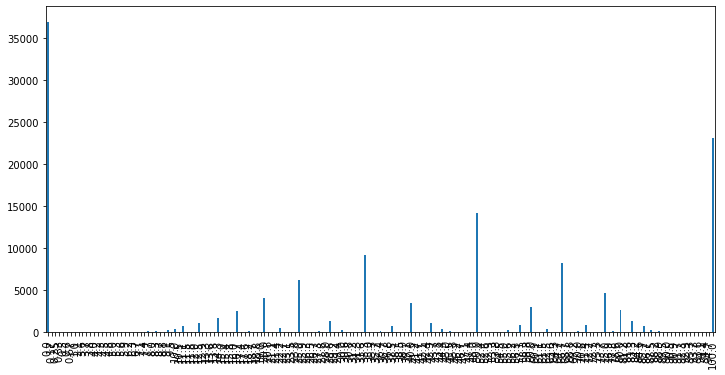

In [21]:
num.porc_tarjetas_75p.value_counts().sort_index().plot.bar(figsize = (12,6));

La categoría mayoritaria es cero.

Imputaremos por cero.

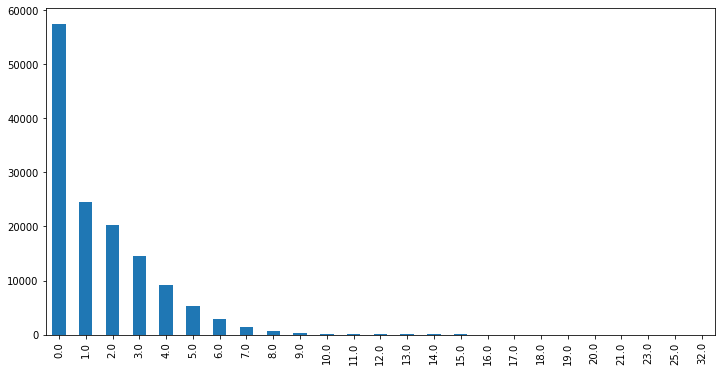

In [22]:
num.num_hipotecas.value_counts().sort_index().plot.bar(figsize = (12,6));

La categoría mayoritaria es cero.

Imputaremos por cero.

Conclusiones:

* imputar todas por ceros

#### Corrección

In [23]:
num.fillna(0,inplace=True)

### Atípicos

#### Por desviación típica

##### Identificación

###### Definir el número de desviaciones típicas

In [24]:
num_desv_tip = 4

###### Función que devuelve los índices de los atípicos

In [25]:
def atipicos_desv_tip(variable, num_desv_tip = 4):
    #sacamos los nulos por ahora
    variable = variable.dropna()
    #calculamos los límites
    media = np.mean(variable)
    sd = np.std(variable)
    umbral = sd * num_desv_tip
    lim_inf = media - umbral
    lim_sup = media + umbral
    #encontramos los índices de los que están fuera de los límites
    indices = [indice for indice,valor in variable.items() if valor < lim_inf or valor > lim_sup]
    return(indices)

###### Función que cuenta el número de atípicos

In [26]:
def conteo_atipicos(df,variable, num_desv_tip = 4):
    atipicos = atipicos_desv_tip(df[variable], num_desv_tip)
    return(df.loc[atipicos,variable].value_counts().sort_index())

###### Variables a aplicar

In [27]:
var_atipicos_dt = ['ingresos','principal','imp_cuota','imp_recuperado']

###### Aplicar

In [28]:
for variable in var_atipicos_dt:
    print('\n' + variable + ':\n')
    print(conteo_atipicos(num,variable,num_desv_tip))


ingresos:

430,000.00       3
430,644.00       1
432,000.00       1
432,824.00       1
435,000.00       4
                ..
7,845,315.00     1
8,500,021.00     1
9,550,000.00     1
9,573,072.00     1
10,999,200.00    1
Name: ingresos, Length: 136, dtype: int64

principal:

Series([], Name: principal, dtype: int64)

imp_cuota:

1,535.71    1
1,566.80    2
1,587.02    1
1,607.80    1
1,714.54    1
Name: imp_cuota, dtype: int64

imp_recuperado:

3,239.75     1
3,240.00     1
3,240.79     1
3,240.90     1
3,241.68     1
            ..
24,383.06    1
26,172.99    1
27,657.68    1
33,407.16    1
33,666.34    1
Name: imp_recuperado, Length: 1591, dtype: int64


Revisamos con más detalle la variable ingresos.

In [29]:
num.ingresos.describe()

count      140,000.00
mean        78,292.11
std         87,857.29
min              0.00
25%         46,100.00
50%         65,000.00
75%         93,000.00
max     10,999,200.00
Name: ingresos, dtype: float64

##### Corrección

Eliminar los registros con ingresos superiores a 300.000$

###### Id de registros a eliminar

In [30]:
a_eliminar = num.loc[num.ingresos > 300000].index.values
a_eliminar

array([   601669, 115087816,  83678168,  75468055, 104953803,  68355962,
        60525500,  59101444,  74703269,  70631462,  26329813, 114093587,
       121891976, 145133997, 141509839,  70701688,  74845067, 113905376,
        91162705,  69967314,  79015002,  33371205,  88195703, 114793732,
       115048244,   9746316, 110905405,  93634763,  75358546,  39559363,
        65038134,  70592833, 107733336,  77517938,  93092543,  91131807,
       122689487,  57074442, 133401013,  60831304,  40942257,  79492925,
       116881558, 115085050,   3630153,  78419419,  79390430, 141591423,
        67427919,  60963266, 102523636, 128067879, 125219862,  88921166,
        65087421,  18895853, 109743090, 109322909, 141468030,  92035926,
       137347897,  53252537,  60873988, 144125851,  12938159, 107355068,
       104110402,  65795964,  59242936, 125737574, 132251779, 134479546,
       104319520, 145242693,   2367546,  79081285,  40385541, 120150582,
       124877413, 125330617, 122347658, 140598256, 

###### Aplicar

In [31]:
cat = cat[~cat.index.isin(a_eliminar)]
num = num[~num.index.isin(a_eliminar)]

## GUARDAR DATASETS TRAS CALIDAD DE DATOS

### Definir los nombres de los archivos

In [32]:
ruta_trabajo = INTERIM_DATA_DIR / 'trabajo_resultado_calidad.pickle'
ruta_cat = INTERIM_DATA_DIR / 'cat_resultado_calidad.pickle'
ruta_num = INTERIM_DATA_DIR / 'num_resultado_calidad.pickle'

### Guardar los archivos

In [33]:
df.to_pickle(ruta_trabajo)
cat.to_pickle(ruta_cat)
num.to_pickle(ruta_num)